In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
input_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\grayscale_frames\match1"

In [3]:
frame_files = sorted(os.listdir(input_folder))

print("Total grayscale frames:", len(frame_files))

Total grayscale frames: 164


In [4]:
sample_frames = frame_files[0:10]

print("Frames selected for noise analysis:")
print(sample_frames)

Frames selected for noise analysis:
['frame_0000.jpg', 'frame_0001.jpg', 'frame_0002.jpg', 'frame_0003.jpg', 'frame_0004.jpg', 'frame_0005.jpg', 'frame_0006.jpg', 'frame_0007.jpg', 'frame_0008.jpg', 'frame_0009.jpg']


In [5]:
def analyze_all_noises(image):
    
    mean_val = np.mean(image)
    std_val = np.std(image)
    variance = np.var(image)

    dark_pixels = np.sum(image <= 5)
    bright_pixels = np.sum(image >= 250)
    total_pixels = image.size

    dark_ratio = dark_pixels / total_pixels
    bright_ratio = bright_pixels / total_pixels
    impulse_ratio = dark_ratio + bright_ratio

    vmr = variance / mean_val if mean_val != 0 else 0

    results = {}

    # 1. Gaussian Noise
    if std_val > 20 and impulse_ratio < 0.01 and not (0.8 <= vmr <= 1.2):
        results["Gaussian"] = (
            "Present",
            f"Std Dev = {std_val:.2f} is high, impulse ratio = {impulse_ratio:.4f} is low, and VMR = {vmr:.2f} is not close to 1."
        )
    else:
        results["Gaussian"] = (
            "Not Present",
            f"Conditions not strong enough for Gaussian noise: Std Dev = {std_val:.2f}, impulse ratio = {impulse_ratio:.4f}, VMR = {vmr:.2f}."
        )

    # 2. Salt-and-Pepper Noise
    if impulse_ratio >= 0.05:
        results["Salt-and-Pepper"] = (
            "Present",
            f"Impulse ratio = {impulse_ratio:.4f} (>5%), showing many extreme dark/bright pixels."
        )
    elif impulse_ratio >= 0.01:
        results["Salt-and-Pepper"] = (
            "Weakly Present",
            f"Impulse ratio = {impulse_ratio:.4f} (between 1% and 5%), indicating some impulse noise."
        )
    else:
        results["Salt-and-Pepper"] = (
            "Not Present",
            f"Impulse ratio = {impulse_ratio:.4f} (<1%), so extreme pixels are too few to confirm salt-and-pepper noise."
        )

    # 3. Speckle Noise
    if variance > 1000 and vmr > 2 and impulse_ratio < 0.01:
        results["Speckle"] = (
            "Present",
            f"Variance = {variance:.2f} is high and VMR = {vmr:.2f} > 2, suggesting multiplicative grain-like noise."
        )
    else:
        results["Speckle"] = (
            "Not Present",
            f"Variance = {variance:.2f} and VMR = {vmr:.2f} do not strongly support speckle noise."
        )

    # 4. Poisson Noise
    if 0.8 <= vmr <= 1.2:
        results["Poisson"] = (
            "Present",
            f"VMR = {vmr:.2f}, which is close to 1, matching Poisson noise behavior where variance is close to mean."
        )
    else:
        results["Poisson"] = (
            "Not Present",
            f"VMR = {vmr:.2f}, which is not close to 1, so Poisson noise is not supported."
        )

    stats = {
        "Mean": mean_val,
        "Std Dev": std_val,
        "Variance": variance,
        "Variance-to-Mean Ratio": vmr,
        "Dark Pixel Ratio": dark_ratio,
        "Bright Pixel Ratio": bright_ratio,
        "Impulse Ratio": impulse_ratio
    }

    return stats, results

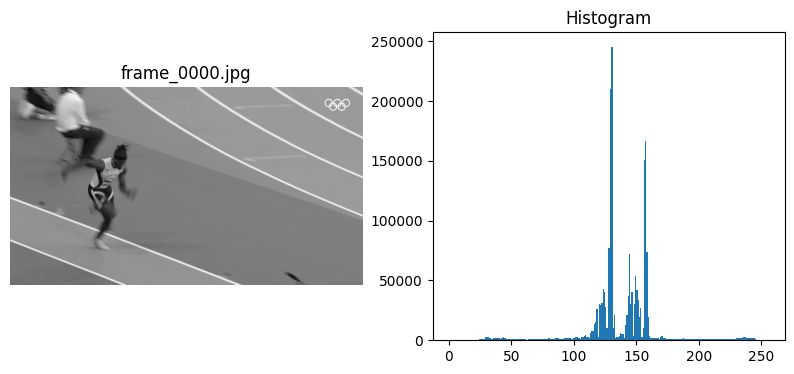

Frame: frame_0000.jpg
Mean: 138.26
Std Dev: 28.37
Variance: 804.69
Variance-to-Mean Ratio: 5.82
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.0008
Impulse Ratio: 0.0008

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 28.37 is high, impulse ratio = 0.0008 is low, and VMR = 5.82 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0008 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 804.69 and VMR = 5.82 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 5.82, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


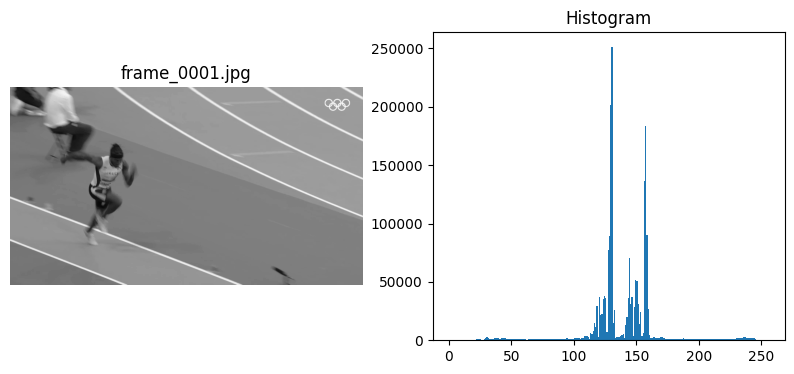

Frame: frame_0001.jpg
Mean: 138.8
Std Dev: 28.23
Variance: 797.06
Variance-to-Mean Ratio: 5.74
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.0008
Impulse Ratio: 0.0008

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 28.23 is high, impulse ratio = 0.0008 is low, and VMR = 5.74 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0008 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 797.06 and VMR = 5.74 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 5.74, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


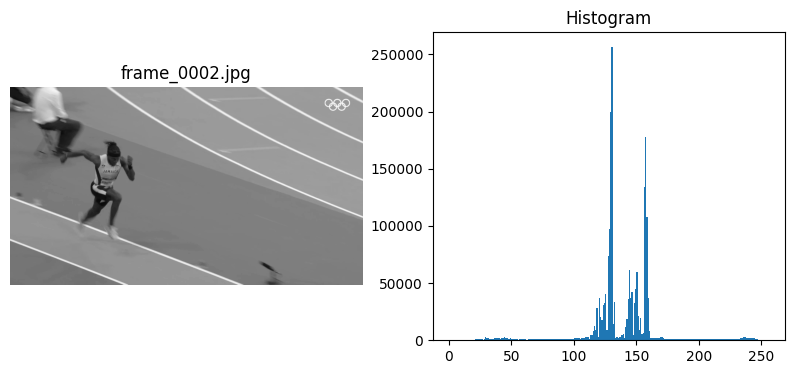

Frame: frame_0002.jpg
Mean: 138.95
Std Dev: 28.46
Variance: 809.79
Variance-to-Mean Ratio: 5.83
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.0008
Impulse Ratio: 0.0008

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 28.46 is high, impulse ratio = 0.0008 is low, and VMR = 5.83 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0008 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 809.79 and VMR = 5.83 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 5.83, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


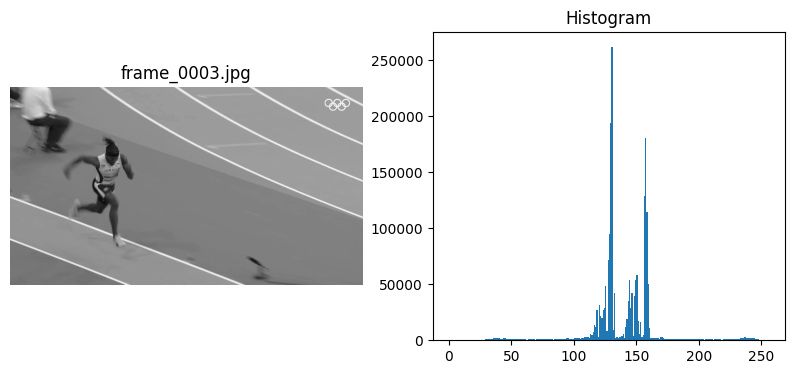

Frame: frame_0003.jpg
Mean: 139.38
Std Dev: 27.85
Variance: 775.86
Variance-to-Mean Ratio: 5.57
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.0009
Impulse Ratio: 0.0009

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 27.85 is high, impulse ratio = 0.0009 is low, and VMR = 5.57 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0009 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 775.86 and VMR = 5.57 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 5.57, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


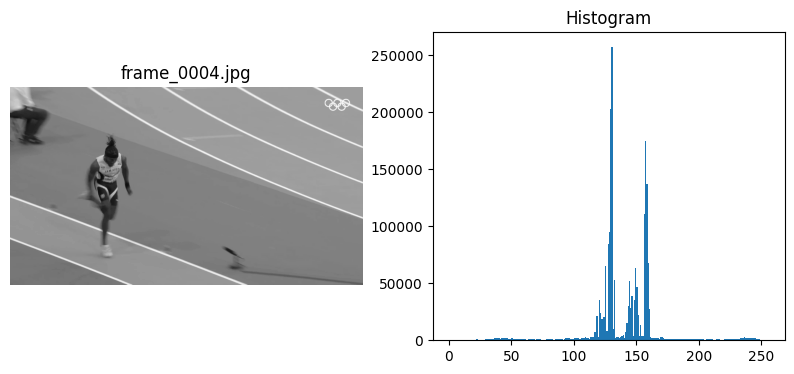

Frame: frame_0004.jpg
Mean: 139.6
Std Dev: 27.55
Variance: 759.13
Variance-to-Mean Ratio: 5.44
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.0009
Impulse Ratio: 0.0009

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 27.55 is high, impulse ratio = 0.0009 is low, and VMR = 5.44 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0009 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 759.13 and VMR = 5.44 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 5.44, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


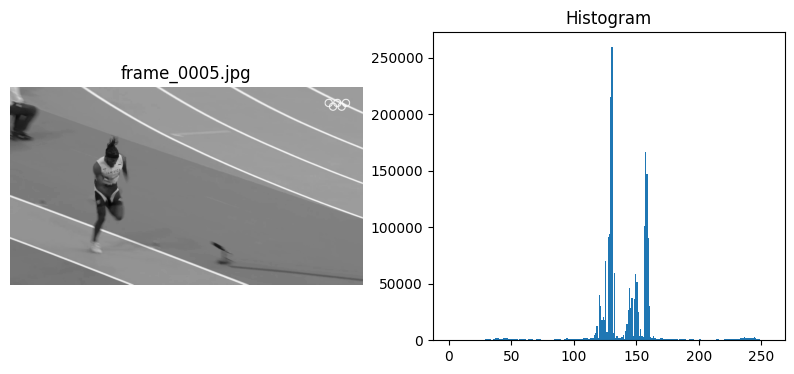

Frame: frame_0005.jpg
Mean: 140.0
Std Dev: 26.72
Variance: 713.71
Variance-to-Mean Ratio: 5.1
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.001
Impulse Ratio: 0.001

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 26.72 is high, impulse ratio = 0.0010 is low, and VMR = 5.10 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0010 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 713.71 and VMR = 5.10 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 5.10, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


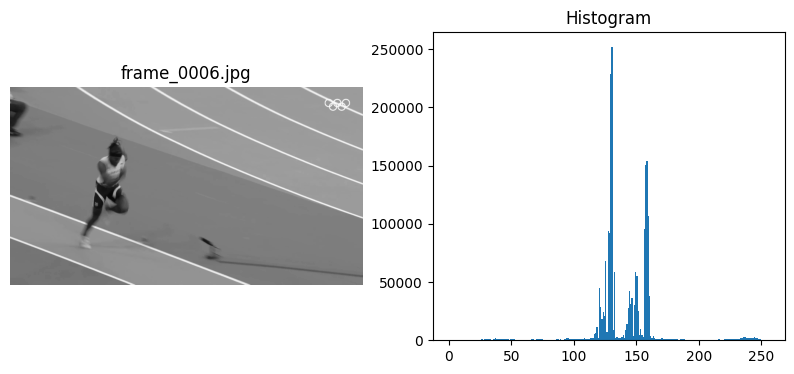

Frame: frame_0006.jpg
Mean: 140.45
Std Dev: 25.98
Variance: 674.93
Variance-to-Mean Ratio: 4.81
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.001
Impulse Ratio: 0.001

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 25.98 is high, impulse ratio = 0.0010 is low, and VMR = 4.81 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0010 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 674.93 and VMR = 4.81 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 4.81, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


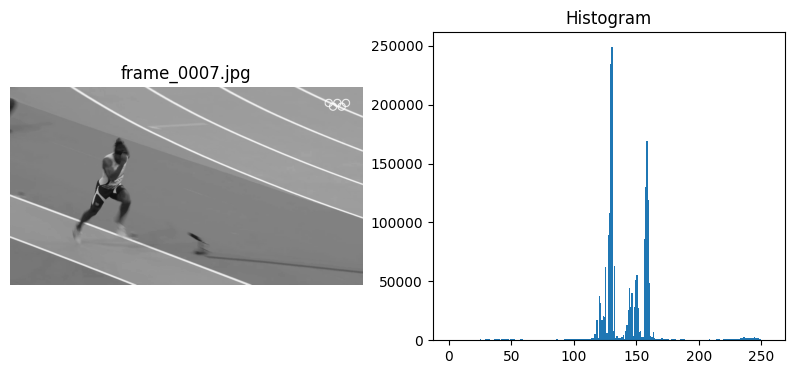

Frame: frame_0007.jpg
Mean: 140.99
Std Dev: 25.33
Variance: 641.76
Variance-to-Mean Ratio: 4.55
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.001
Impulse Ratio: 0.001

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 25.33 is high, impulse ratio = 0.0010 is low, and VMR = 4.55 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0010 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 641.76 and VMR = 4.55 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 4.55, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


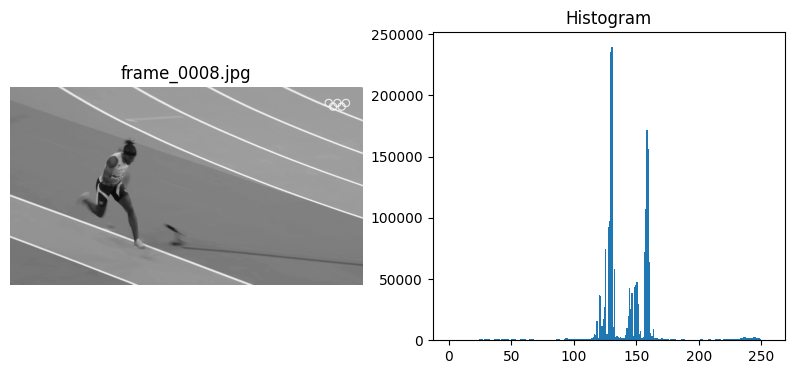

Frame: frame_0008.jpg
Mean: 141.3
Std Dev: 25.73
Variance: 662.17
Variance-to-Mean Ratio: 4.69
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.001
Impulse Ratio: 0.001

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 25.73 is high, impulse ratio = 0.0010 is low, and VMR = 4.69 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0010 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 662.17 and VMR = 4.69 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 4.69, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


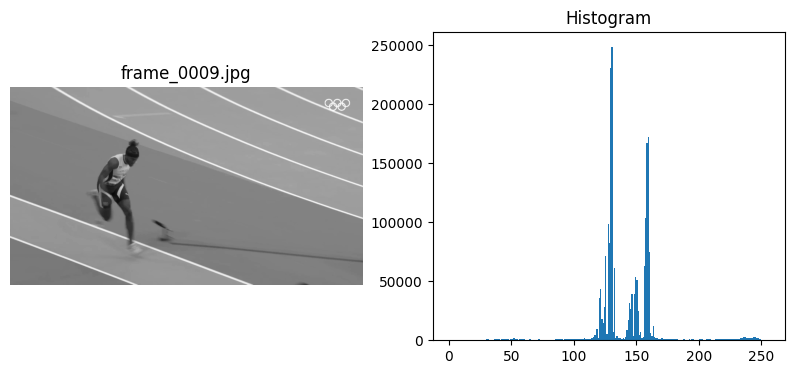

Frame: frame_0009.jpg
Mean: 141.52
Std Dev: 26.0
Variance: 675.98
Variance-to-Mean Ratio: 4.78
Dark Pixel Ratio: 0.0
Bright Pixel Ratio: 0.0011
Impulse Ratio: 0.0011

Noise Analysis and Proof:

1. Gaussian Noise: Present
Proof: Std Dev = 26.00 is high, impulse ratio = 0.0011 is low, and VMR = 4.78 is not close to 1.

2. Salt-and-Pepper Noise: Not Present
Proof: Impulse ratio = 0.0011 (<1%), so extreme pixels are too few to confirm salt-and-pepper noise.

3. Speckle Noise: Not Present
Proof: Variance = 675.98 and VMR = 4.78 do not strongly support speckle noise.

4. Poisson Noise: Not Present
Proof: VMR = 4.78, which is not close to 1, so Poisson noise is not supported.

------------------------------------------------------------


In [6]:
for file in sample_frames:

    image_path = os.path.join(input_folder, file)
    img = cv2.imread(image_path, 0)

    stats, results = analyze_all_noises(img)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(file)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.hist(img.ravel(), bins=256, range=(0,256))
    plt.title("Histogram")

    plt.show()

    print("Frame:", file)
    print("Mean:", round(stats["Mean"], 2))
    print("Std Dev:", round(stats["Std Dev"], 2))
    print("Variance:", round(stats["Variance"], 2))
    print("Variance-to-Mean Ratio:", round(stats["Variance-to-Mean Ratio"], 2))
    print("Dark Pixel Ratio:", round(stats["Dark Pixel Ratio"], 4))
    print("Bright Pixel Ratio:", round(stats["Bright Pixel Ratio"], 4))
    print("Impulse Ratio:", round(stats["Impulse Ratio"], 4))

    print("\nNoise Analysis and Proof:")

    print("\n1. Gaussian Noise:", results["Gaussian"][0])
    print("Proof:", results["Gaussian"][1])

    print("\n2. Salt-and-Pepper Noise:", results["Salt-and-Pepper"][0])
    print("Proof:", results["Salt-and-Pepper"][1])

    print("\n3. Speckle Noise:", results["Speckle"][0])
    print("Proof:", results["Speckle"][1])

    print("\n4. Poisson Noise:", results["Poisson"][0])
    print("Proof:", results["Poisson"][1])

    print("\n" + "-" * 60)